In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [54]:
#LOAD DATASET 
df = pd.read_csv(r"/Users/jiyasahni/physhingDetection/hybrid-phishing-detection/data/processed/clean_dataset.csv")

print(df.head())
print(df.shape)

                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb  ...  Pay  Crypt

In [55]:
# yaha features select kerte hai 
selected = pd.read_csv(
    r"/Users/jiyasahni/physhingDetection/hybrid-phishing-detection/data/processed/selected_features.csv"
)

print(selected.head())
print(selected.shape)

                Feature  IG Score  MI Score
0            LineOfCode  0.028579  0.600887
1               IsHTTPS  0.001286  0.257894
2             URLLength  0.000000  0.168454
3  CharContinuationRate  0.000000  0.172746
4      LetterRatioInURL  0.000000  0.381220
(10, 3)


In [56]:
# yaha se x and y bana rhe hai 
selected_features = selected["Feature"].tolist()

X = df[selected_features]
y = df["label"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print(X.head())

Shape of X: (235795, 10)
Shape of y: (235795,)
   LineOfCode  IsHTTPS  URLLength  CharContinuationRate  LetterRatioInURL  \
0         558        1         31              1.000000             0.581   
1         618        1         23              0.666667             0.391   
2         467        1         29              0.866667             0.517   
3        6356        1         26              1.000000             0.500   
4        6089        1         33              1.000000             0.606   

   NoOfDegitsInURL  DegitRatioInURL  NoOfOtherSpecialCharsInURL  \
0                0              0.0                           1   
1                0              0.0                           2   
2                0              0.0                           2   
3                0              0.0                           1   
4                0              0.0                           1   

   SpacialCharRatioInURL  LargestLineLength  
0                  0.032               93

In [57]:
# train test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (188636, 10)
Testing Data Shape: (47159, 10)


In [58]:
#random forest trainnn
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [59]:
#prediction
y_pred = rf.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9997
Precision: 0.9999
Recall   : 0.9997
F1 Score : 0.9998


In [61]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[20185     4]
 [    9 26961]]


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [63]:
print(selected_features)

['LineOfCode', 'IsHTTPS', 'URLLength', 'CharContinuationRate', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'LargestLineLength']


In [64]:
print(df.columns.tolist())

['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [65]:
print(df["label"].value_counts())

label
1    134850
0    100945
Name: count, dtype: int64


In [66]:
print(df.duplicated().sum())


0


In [67]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.9995759  0.99953349 0.99970313 0.9995547  0.99978795]
Mean Accuracy: 0.9996310354333214


In [68]:
results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

results.to_csv(
    "../results/random_forest_metrics.csv",
    index=False
)

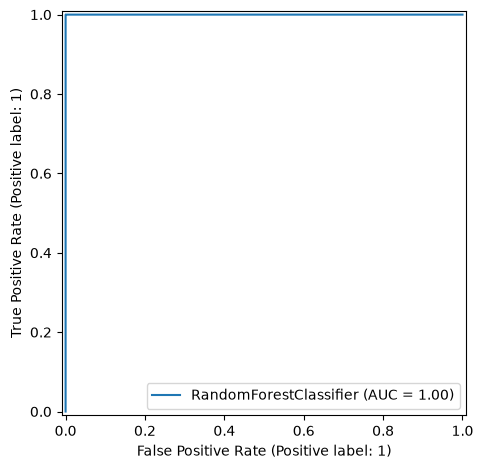

In [69]:
RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.tight_layout()

plt.savefig("../reports/figures/roc_rf.png")

plt.show()

In [70]:
# save the model
import joblib
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']